# Theia — Biological validation (AI vs. expert digitization)

**Manuscript MEE-26-04-354.** We validate the raw predictions of the on-device TFLite model (no human editing) against
expert manual digitization (tpsDig2) on **268 specimens from five populations held out from the model's
training pool**. Because the manual landmarks are shape-only (tpsDig gives no common image scale), the
comparison is made in **geometric-morphometric space**: independent Generalized Procrustes Analyses,
a combined GPA, a Procrustes ANOVA (`coords ~ Individual + Method`), correlations reported **separately**
for centroid size and each principal component, and a **per-landmark Procrustes RMSE**.


In [1]:
%matplotlib inline
import glob, re, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
warnings.filterwarnings("ignore")

# Portable data location (works from the repo and from the working folder).
CANDIDATES = [Path("../data"), Path("../theia_repo/data"),
              Path("/Users/crismbp/Projects/theia/theia_repo/data")]
DATA_DIR = next(p for p in CANDIDATES if (p / "validation_datates").exists())
VAL_DIR = DATA_DIR / "validation_datates"

# Raw on-device TFLite predictions (produced by 02_infer_tflite.py), one CSV per population.
PRED_CANDIDATES = [Path("predictions/pose_lowaug_tflite"),
                   Path("validation_scripts/predictions/pose_lowaug_tflite"),
                   Path("/Users/crismbp/Projects/theia/theia_repo/validation_scripts/predictions/pose_lowaug_tflite")]
PRED_DIR = next((p for p in PRED_CANDIDATES if p.exists()), PRED_CANDIDATES[0])

# Five populations held out from the training pool, each with manual tpsDig landmarks
# and raw Theia predictions.
POPS = ["En11-07", "Ene05-09", "Ewi02-06", "Ewi03-07", "H01-07"]

print("DATA_DIR :", DATA_DIR.resolve())
print("PRED_DIR :", PRED_DIR.resolve())
print("geomorph :", ro.r('as.character(packageVersion("geomorph"))')[0])
importr("geomorph"); ro.r("options(warn=-1)")


DATA_DIR : /Users/crismbp/Projects/theia/theia_repo/data
PRED_DIR : /Users/crismbp/Projects/theia/theia_repo/validation_scripts/predictions/pose_lowaug_tflite
geomorph : 4.0.10


## Assemble the arrays and run the geometric-morphometric comparison

For each population we match manual (tpsDig `.tps`) and Theia (`.csv`) landmarks 1:1 by specimen ID,
then run independent GPAs, a combined GPA, and a Procrustes ANOVA. A Y-axis inversion aligns Theia's
image-matrix coordinate origin with the Cartesian convention used by tpsDig.


In [2]:
def read_tps(fp):
    lines = open(fp, "r", encoding="utf-8", errors="ignore").read().splitlines()
    spec, cur = {}, []
    for line in lines:
        if line.startswith("LM="):
            cur = []
        elif line.startswith("IMAGE="):
            spec[line.split("=")[1].strip()] = np.array(cur, dtype=float)
        elif not line.startswith("ID=") and not line.startswith("SCALE="):
            p = line.split()
            if len(p) >= 2:
                cur.append([float(p[0]), float(p[1])])
    return spec

def assemble(pops):
    """Match manual (.tps) and Theia (.csv) landmarks 1:1 by DSCN id; return (keys, tps, csv)."""
    tps_d, csv_d = {}, {}
    for pop in pops:
        d = VAL_DIR / pop
        tps = glob.glob(str(d / "*.tps"))
        csv = PRED_DIR / f"{pop}__lowaug_tflite__LM.csv"   # raw on-device TFLite predictions
        if not tps or not csv.exists():
            continue
        for k, v in read_tps(tps[0]).items():
            m = re.search(r"(DSCN\d+)", k, re.IGNORECASE)
            if m:
                tps_d[f"{pop}_{m.group(1).upper()}"] = v
        df = pd.read_csv(csv, sep=None, engine="python", encoding="utf-8-sig")
        df.columns = df.columns.str.strip()
        col = "image_name" if "image_name" in df.columns else df.select_dtypes(include=["object"]).columns[0]
        for _, row in df.iterrows():
            m = re.search(r"(DSCN\d+)", str(row[col]), re.IGNORECASE)
            if m:
                c = pd.to_numeric(row.drop(col), errors="coerce").values
                c = c[~np.isnan(c)]
                if len(c):
                    csv_d[f"{pop}_{m.group(1).upper()}"] = c.reshape(-1, 2)
    keys = sorted(set(tps_d) & set(csv_d))
    return keys, np.stack([tps_d[k] for k in keys], 2), np.stack([csv_d[k] for k in keys], 2)

def to_r_array(a):
    return ro.r["array"](ro.FloatVector(a.flatten("F").tolist()), dim=ro.IntVector(list(a.shape)))

def run_geomorph(tps, csv):
    ro.globalenv["A_tps"] = to_r_array(tps); ro.globalenv["A_csv"] = to_r_array(csv)
    ro.r("""
    suppressPackageStartupMessages({library(geomorph); library(abind)})
    n <- dim(A_tps)[3]
    A_csv_m <- A_csv; A_csv_m[,2,] <- -A_csv_m[,2,]          # Y-axis inversion (image vs Cartesian)
    g_man <- gpagen(A_tps, print.progress=FALSE)
    g_ia  <- gpagen(A_csv_m, print.progress=FALSE)
    p_man <- gm.prcomp(g_man$coords); p_ia <- gm.prcomp(g_ia$coords)
    r_cs  <- abs(cor(g_man$Csize, g_ia$Csize))
    r_pc1 <- abs(cor(p_man$x[,1], p_ia$x[,1])); r_pc2 <- abs(cor(p_man$x[,2], p_ia$x[,2]))
    r_pc3 <- abs(cor(p_man$x[,3], p_ia$x[,3]))
    g_comb <- gpagen(abind(A_tps, A_csv_m, along=3), print.progress=FALSE)
    ind <- as.factor(rep(1:n, 2)); met <- as.factor(c(rep("Manual", n), rep("Theia", n)))
    aov <- procD.lm(coords ~ ind + met,
                    data=geomorph.data.frame(coords=g_comb$coords, ind=ind, met=met),
                    iter=999, print.progress=FALSE)$aov.table
    R2_ind <- aov["ind","Rsq"]; R2_met <- aov["met","Rsq"]; p_met <- aov["met","Pr(>F)"]
    K <- dim(g_comb$coords)[1]; lm_sq <- matrix(0, K, n)
    for (i in 1:n) lm_sq[,i] <- rowSums((g_comb$coords[,,i] - g_comb$coords[,,(i+n)])^2)
    perlm <- sqrt(rowMeans(lm_sq))                            # per-landmark Procrustes RMSE
    """)
    g = ro.globalenv; s = lambda x: float(g[x][0])
    return dict(n=tps.shape[2], r_cs=s("r_cs"), r_pc1=s("r_pc1"), r_pc2=s("r_pc2"), r_pc3=s("r_pc3"),
                R2_ind=s("R2_ind"), R2_met=s("R2_met"), p_met=s("p_met"),
                perlm=np.asarray(list(g["perlm"])))

keys, tps, csv = assemble(POPS)
res = run_geomorph(tps, csv)

print(f"Populations (held out from training): {POPS}")
print(f"N = {res['n']} specimens (raw Theia predictions vs manual tpsDig)\n")
print("Separate correlations (|r|):")
print(f"  Centroid size : {res['r_cs']:.4f}")
print(f"  PC1 scores    : {res['r_pc1']:.4f}")
print(f"  PC2 scores    : {res['r_pc2']:.4f}")
print(f"  PC3 scores    : {res['r_pc3']:.4f}")
print("\nProcrustes ANOVA (coords ~ Individual + Method):")
print(f"  Individual (biological) : R2 = {res['R2_ind']:.4f}  ({res['R2_ind']*100:.2f}%)")
print(f"  Method (AI vs manual)   : R2 = {res['R2_met']:.4f}  ({res['R2_met']*100:.2f}%)   p = {res['p_met']:.3f}")
print(f"  Signal:bias ratio       : {res['R2_ind']/res['R2_met']:.2f} : 1")


Populations (held out from training): ['En11-07', 'Ene05-09', 'Ewi02-06', 'Ewi03-07', 'H01-07']
N = 268 specimens (raw Theia predictions vs manual tpsDig)

Separate correlations (|r|):
  Centroid size : 0.9556
  PC1 scores    : 0.9785
  PC2 scores    : 0.9484
  PC3 scores    : 0.8855

Procrustes ANOVA (coords ~ Individual + Method):
  Individual (biological) : R2 = 0.7848  (78.48%)
  Method (AI vs manual)   : R2 = 0.1515  (15.15%)   p = 0.001
  Signal:bias ratio       : 5.18 : 1


## Per-landmark agreement (Procrustes RMSE)

The per-landmark RMSE in Procrustes shape space localizes the disagreement across all shape axes
(not just PC1–PC2). Higher values fall on peripheral landmarks, consistent with the systematic,
slightly centripetal method offset discussed in the manuscript.


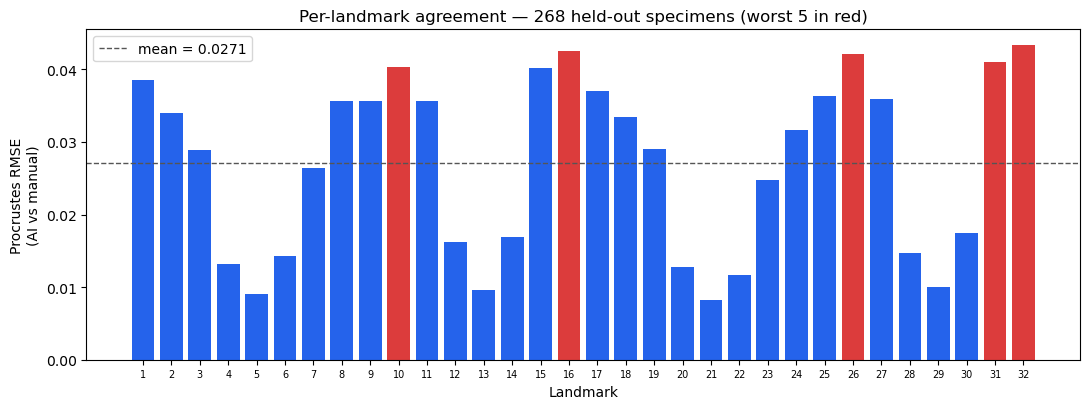

mean RMSE = 0.0271  min = 0.0082  max = 0.0433  (Procrustes units)
worst 5 landmarks (1-indexed): [32, 16, 26, 31, 10]


In [3]:
perlm = res["perlm"]; K = len(perlm)
order = np.argsort(perlm)[::-1]; worst = set(order[:5])
colors = ["#dc3c3c" if i in worst else "#2563eb" for i in range(K)]
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.bar(np.arange(1, K + 1), perlm, color=colors)
ax.axhline(perlm.mean(), color="#555", ls="--", lw=1, label=f"mean = {perlm.mean():.4f}")
ax.set_xlabel("Landmark"); ax.set_ylabel("Procrustes RMSE\n(AI vs manual)")
ax.set_title(f'Per-landmark agreement — {res["n"]} held-out specimens (worst 5 in red)')
ax.set_xticks(np.arange(1, K + 1, 1)); ax.tick_params(axis="x", labelsize=7); ax.legend()
plt.tight_layout(); plt.show()
print(f"mean RMSE = {perlm.mean():.4f}  min = {perlm.min():.4f}  max = {perlm.max():.4f}  (Procrustes units)")
print(f"worst 5 landmarks (1-indexed): {[int(i) + 1 for i in order[:5]]}")
